Unser Model für die VL: 

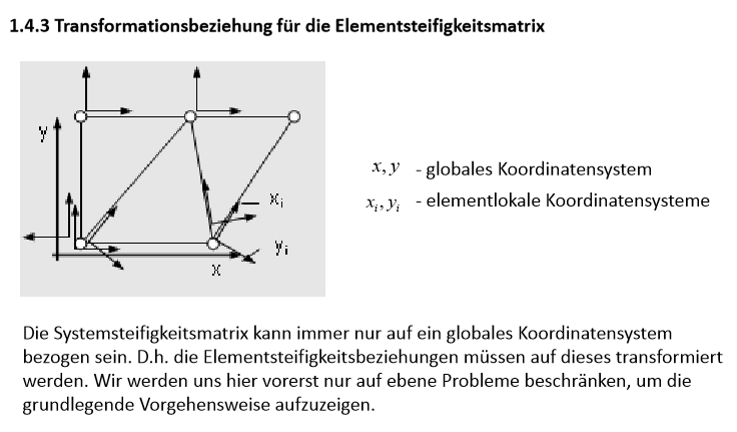

Aufbau eine Tranformationsmatrix

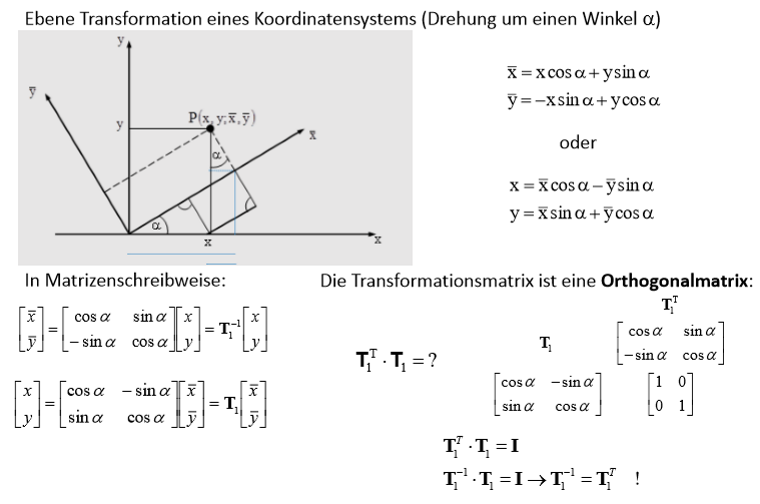

In [1]:
import numpy as np
import sympy as sp

In [ ]:
alpha = sp.symbols("alpha", real = "True")
T = sp.Matrix([
    [sp.cos(alpha), -sp.sin(alpha)],
    [sp.sin(alpha),  sp.cos(alpha)]
]
)

Matrix([
[cos(alpha), -sin(alpha)],
[sin(alpha),  cos(alpha)]])

In [5]:
A = sp.Matrix([[0.5],[0.5]])

In [7]:
B = T@A

In [9]:
T_30deg = T.subs(alpha, 30*sp.pi/180)

Erweitern der Steifigkeitsmatrix auf 4 Freiheitsgrade. 
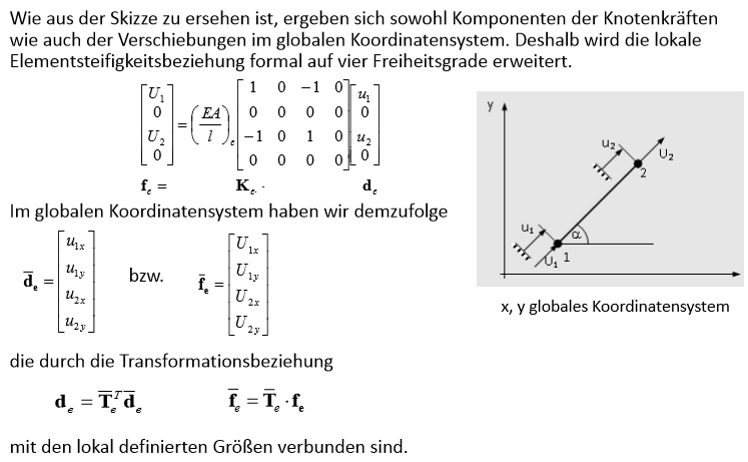

d = Verschiebung
f = Kräfte

\bar d = Verschiebung in 4 Dimensionen
\bar f = Kräfte in 4 Dimensionen

In [11]:
# Aus VL1
n = 2
K_np = (np.diag(np.ones(n))                
        + np.diag(-np.ones(n-1),  1)       
        + np.diag(-np.ones(n-1), -1))      
K_np[0, -1] = -1
K = sp.Matrix(K_np)
K

Matrix([
[ 1.0, -1.0],
[-1.0,  1.0]])

Idee: 

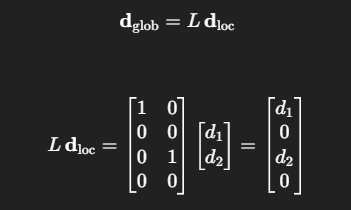

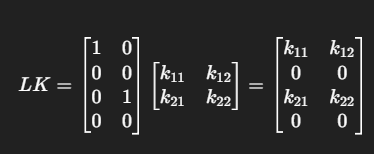

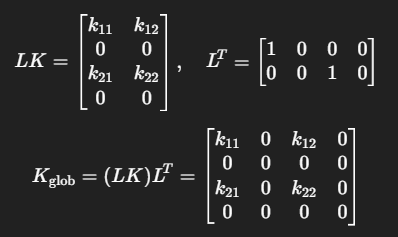

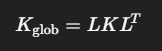

In [13]:
# Einbettungsmatrix L: mappe lokale DOFs -> globale DOFs (0 und 2)
L = sp.Matrix([
    [1, 0],   # global DOF 0   <-- local DOF 0
    [0, 0],   # global DOF 1   <-- nichts
    [0, 1],   # global DOF 2   <-- local DOF 1
    [0, 0],   # global DOF 3   <-- nichts
])
L


Matrix([
[1, 0],
[0, 0],
[0, 1],
[0, 0]])

In [15]:
L.T

Matrix([
[1, 0, 0, 0],
[0, 0, 1, 0]])

In [14]:
K4 = L * K * L.T              # 4x4-Steifigkeitsmatrix
K4

Matrix([
[ 1.0, 0, -1.0, 0],
[   0, 0,    0, 0],
[-1.0, 0,  1.0, 0],
[   0, 0,    0, 0]])

In [ ]:
# Verschiebungen
u_1x = sp.symbols("u_1x", real = True)
u_1y = sp.symbols("u_1y", real = True)
u_2x = sp.symbols("u_2x", real = True)
u_2y = sp.symbols("u_2y", real = True)
d_estrich = sp.Matrix([
    [u_1x],
    [u_1y],
    [u_2x],
    [u_2y]
])
d_estrich

Matrix([
[u_1x],
[u_1y],
[u_2x],
[u_2y]])

In [ ]:
# Kräfte
U_1x = sp.symbols("U_1x", real = True)
U_1y = sp.symbols("U_1y", real = True)
U_2x = sp.symbols("U_2x", real = True)
U_2y = sp.symbols("U_2y", real = True)
f_estrich = sp.Matrix([
    [U_1x],
    [U_1y],
    [U_2x],
    [U_2y]
])
f_estrich 

Matrix([
[U_1x],
[U_1y],
[U_2x],
[U_2y]])

Nun zu dieser Folie: 

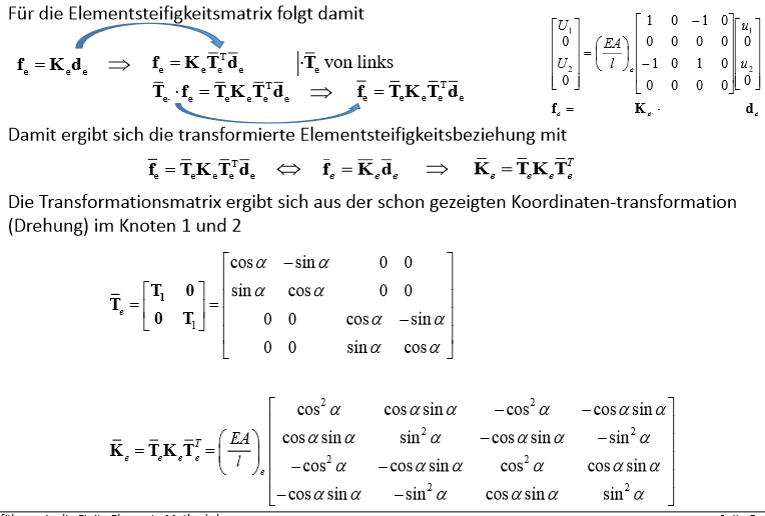

In [21]:
# Herleitung verstanden, weiter geht es.

# Erweitere die Matrix T
T_estrich = sp.diag(T, T) 
T_estrich

Matrix([
[cos(alpha), -sin(alpha),          0,           0],
[sin(alpha),  cos(alpha),          0,           0],
[         0,           0, cos(alpha), -sin(alpha)],
[         0,           0, sin(alpha),  cos(alpha)]])

In [40]:
E = sp.symbols("E")
A = sp.symbols("A")
l = sp.symbols("l")

In [41]:
K_r = (E*A/l)*K4
K_r

Matrix([
[ 1.0*A*E/l, 0, -1.0*A*E/l, 0],
[         0, 0,          0, 0],
[-1.0*A*E/l, 0,  1.0*A*E/l, 0],
[         0, 0,          0, 0]])

In [43]:
K_estrich = T_estrich@K_r@T_estrich.T
K_estrich

Matrix([
[         1.0*A*E*cos(alpha)**2/l,  1.0*A*E*sin(alpha)*cos(alpha)/l,         -1.0*A*E*cos(alpha)**2/l, -1.0*A*E*sin(alpha)*cos(alpha)/l],
[ 1.0*A*E*sin(alpha)*cos(alpha)/l,          1.0*A*E*sin(alpha)**2/l, -1.0*A*E*sin(alpha)*cos(alpha)/l,         -1.0*A*E*sin(alpha)**2/l],
[        -1.0*A*E*cos(alpha)**2/l, -1.0*A*E*sin(alpha)*cos(alpha)/l,          1.0*A*E*cos(alpha)**2/l,  1.0*A*E*sin(alpha)*cos(alpha)/l],
[-1.0*A*E*sin(alpha)*cos(alpha)/l,         -1.0*A*E*sin(alpha)**2/l,  1.0*A*E*sin(alpha)*cos(alpha)/l,          1.0*A*E*sin(alpha)**2/l]])

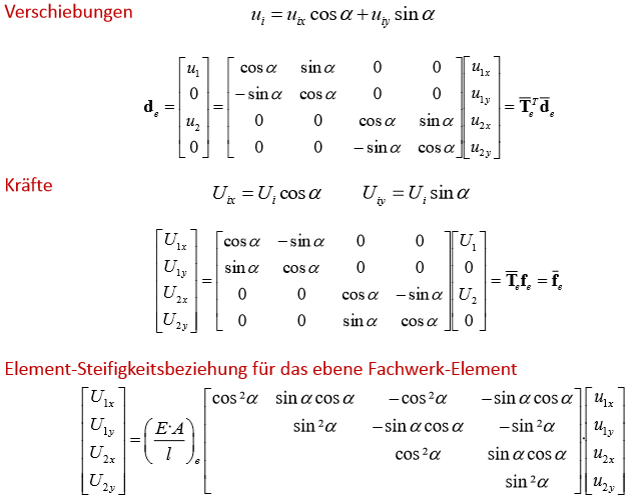

In [44]:
# Umwandeln der Verschiebungen
# Zusammenhang zwischen lokalen und globalen Verschiebungs‐DOFs
u_1 = sp.symbols("u_1")
u_2 = sp.symbols("u_2")
d_e  = sp.Matrix([u_1, 0, u_2, 0])  
d_e

Matrix([
[u_1],
[  0],
[u_2],
[  0]])

In [45]:
eq_local_global_disp = sp.Eq(d_e,T_estrich.T@d_estrich)
eq_local_global_disp

Eq(Matrix([
[u_1],
[  0],
[u_2],
[  0]]), Matrix([
[ u_1x*cos(alpha) + u_1y*sin(alpha)],
[-u_1x*sin(alpha) + u_1y*cos(alpha)],
[ u_2x*cos(alpha) + u_2y*sin(alpha)],
[-u_2x*sin(alpha) + u_2y*cos(alpha)]]))

In [46]:
U_1 = sp.symbols("U_1")
U_2 = sp.symbols("U_2")
f_e = sp.Matrix([U_1, 0, U_2, 0])
f_e

Matrix([
[U_1],
[  0],
[U_2],
[  0]])

In [47]:
# Zusammenhang zwischen globalen und lokalen  Kräfte‐DOFs
eq_force_transform = sp.Eq(f_estrich, T_estrich@f_e)
eq_force_transform 

Eq(Matrix([
[U_1x],
[U_1y],
[U_2x],
[U_2y]]), Matrix([
[U_1*cos(alpha)],
[U_1*sin(alpha)],
[U_2*cos(alpha)],
[U_2*sin(alpha)]]))

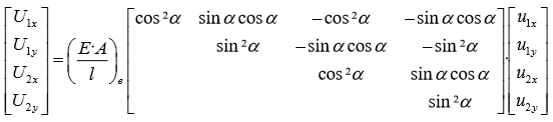

In [48]:
# Element-Steifigkeitsbeziehung für das ebene Fachwerk-Element
eq_truss_element_stiffnes = sp.Eq(f_estrich, K_estrich@d_estrich)
eq_truss_element_stiffnes

Eq(Matrix([
[U_1x],
[U_1y],
[U_2x],
[U_2y]]), Matrix([
[ 1.0*A*E*u_1x*cos(alpha)**2/l + 1.0*A*E*u_1y*sin(alpha)*cos(alpha)/l - 1.0*A*E*u_2x*cos(alpha)**2/l - 1.0*A*E*u_2y*sin(alpha)*cos(alpha)/l],
[ 1.0*A*E*u_1x*sin(alpha)*cos(alpha)/l + 1.0*A*E*u_1y*sin(alpha)**2/l - 1.0*A*E*u_2x*sin(alpha)*cos(alpha)/l - 1.0*A*E*u_2y*sin(alpha)**2/l],
[-1.0*A*E*u_1x*cos(alpha)**2/l - 1.0*A*E*u_1y*sin(alpha)*cos(alpha)/l + 1.0*A*E*u_2x*cos(alpha)**2/l + 1.0*A*E*u_2y*sin(alpha)*cos(alpha)/l],
[-1.0*A*E*u_1x*sin(alpha)*cos(alpha)/l - 1.0*A*E*u_1y*sin(alpha)**2/l + 1.0*A*E*u_2x*sin(alpha)*cos(alpha)/l + 1.0*A*E*u_2y*sin(alpha)**2/l]]))

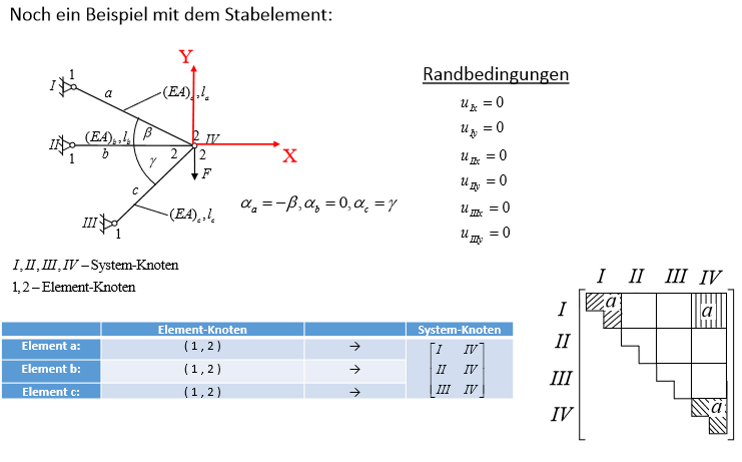

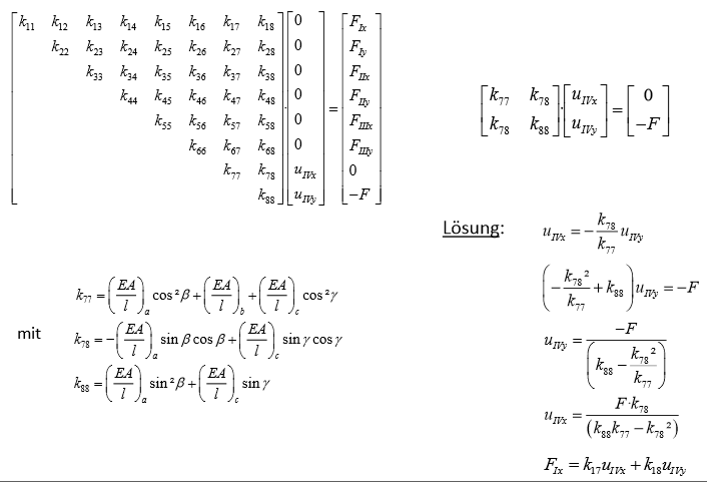

In [52]:
E_a = sp.symbols("E_a")
E_b = sp.symbols("E_b")
E_c = sp.symbols("E_c")

A_a = sp.symbols("A_a")
A_b = sp.symbols("A_b")
A_c = sp.symbols("A_c")

l_a = sp.symbols("l_a")
l_b = sp.symbols("l_b")
l_c = sp.symbols("l_c")

gamma = sp.symbols("gamma")
beta = sp.symbols("beta")

In [53]:
K_a = K_estrich.subs({A: A_a, E: E_a, l: l_a, alpha: -beta})
K_a

Matrix([
[        1.0*A_a*E_a*cos(beta)**2/l_a, -1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,        -1.0*A_a*E_a*cos(beta)**2/l_a,  1.0*A_a*E_a*sin(beta)*cos(beta)/l_a],
[-1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,         1.0*A_a*E_a*sin(beta)**2/l_a,  1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,        -1.0*A_a*E_a*sin(beta)**2/l_a],
[       -1.0*A_a*E_a*cos(beta)**2/l_a,  1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,         1.0*A_a*E_a*cos(beta)**2/l_a, -1.0*A_a*E_a*sin(beta)*cos(beta)/l_a],
[ 1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,        -1.0*A_a*E_a*sin(beta)**2/l_a, -1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,         1.0*A_a*E_a*sin(beta)**2/l_a]])

In [54]:
K_b = K_estrich.subs({A: A_b, E: E_b, l: l_b, alpha: 0})
K_b

Matrix([
[ 1.0*A_b*E_b/l_b, 0, -1.0*A_b*E_b/l_b, 0],
[               0, 0,                0, 0],
[-1.0*A_b*E_b/l_b, 0,  1.0*A_b*E_b/l_b, 0],
[               0, 0,                0, 0]])

In [55]:
K_c = K_estrich.subs({A: A_c, E: E_c, l: l_c, alpha: gamma})
K_c

Matrix([
[         1.0*A_c*E_c*cos(gamma)**2/l_c,  1.0*A_c*E_c*sin(gamma)*cos(gamma)/l_c,         -1.0*A_c*E_c*cos(gamma)**2/l_c, -1.0*A_c*E_c*sin(gamma)*cos(gamma)/l_c],
[ 1.0*A_c*E_c*sin(gamma)*cos(gamma)/l_c,          1.0*A_c*E_c*sin(gamma)**2/l_c, -1.0*A_c*E_c*sin(gamma)*cos(gamma)/l_c,         -1.0*A_c*E_c*sin(gamma)**2/l_c],
[        -1.0*A_c*E_c*cos(gamma)**2/l_c, -1.0*A_c*E_c*sin(gamma)*cos(gamma)/l_c,          1.0*A_c*E_c*cos(gamma)**2/l_c,  1.0*A_c*E_c*sin(gamma)*cos(gamma)/l_c],
[-1.0*A_c*E_c*sin(gamma)*cos(gamma)/l_c,         -1.0*A_c*E_c*sin(gamma)**2/l_c,  1.0*A_c*E_c*sin(gamma)*cos(gamma)/l_c,          1.0*A_c*E_c*sin(gamma)**2/l_c]])

In [68]:
ndof = 8
Kglob = sp.zeros(ndof)
Kglob

Matrix([
[0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0]])

In [69]:
# Zu den DOFs
# Es ist ein Indix für den Knoten
# I_x   = 0
# I_y   = 1
# II_x  = 2
# II_y  = 4  ....usw....

def assemble(Kglob, Ke, dofs):
    """Ke an die globalen DOFs 'dofs' (Liste aus 4 Indizes) anhängen."""
    for i_loc, I in enumerate(dofs):
        for j_loc, J in enumerate(dofs):
            Kglob[I, J] += Ke[i_loc, j_loc]
    return Kglob

In [70]:
Kglob  = assemble(Kglob, K_a, [0, 1, 6, 7])
Kglob

Matrix([
[        1.0*A_a*E_a*cos(beta)**2/l_a, -1.0*A_a*E_a*sin(beta)*cos(beta)/l_a, 0, 0, 0, 0,        -1.0*A_a*E_a*cos(beta)**2/l_a,  1.0*A_a*E_a*sin(beta)*cos(beta)/l_a],
[-1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,         1.0*A_a*E_a*sin(beta)**2/l_a, 0, 0, 0, 0,  1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,        -1.0*A_a*E_a*sin(beta)**2/l_a],
[                                   0,                                    0, 0, 0, 0, 0,                                    0,                                    0],
[                                   0,                                    0, 0, 0, 0, 0,                                    0,                                    0],
[                                   0,                                    0, 0, 0, 0, 0,                                    0,                                    0],
[                                   0,                                    0, 0, 0, 0, 0,                                    0,                                   

In [71]:
Kglob  = assemble(Kglob, K_b, [2, 3, 6, 7])
Kglob

Matrix([
[        1.0*A_a*E_a*cos(beta)**2/l_a, -1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,                0, 0, 0, 0,                  -1.0*A_a*E_a*cos(beta)**2/l_a,  1.0*A_a*E_a*sin(beta)*cos(beta)/l_a],
[-1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,         1.0*A_a*E_a*sin(beta)**2/l_a,                0, 0, 0, 0,            1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,        -1.0*A_a*E_a*sin(beta)**2/l_a],
[                                   0,                                    0,  1.0*A_b*E_b/l_b, 0, 0, 0,                               -1.0*A_b*E_b/l_b,                                    0],
[                                   0,                                    0,                0, 0, 0, 0,                                              0,                                    0],
[                                   0,                                    0,                0, 0, 0, 0,                                              0,                                    0],
[                                   

In [72]:
Kglob  = assemble(Kglob, K_c, [4, 5, 6, 7])
Kglob

Matrix([
[        1.0*A_a*E_a*cos(beta)**2/l_a, -1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,                0, 0,                                      0,                                      0,                                                  -1.0*A_a*E_a*cos(beta)**2/l_a,                                          1.0*A_a*E_a*sin(beta)*cos(beta)/l_a],
[-1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,         1.0*A_a*E_a*sin(beta)**2/l_a,                0, 0,                                      0,                                      0,                                            1.0*A_a*E_a*sin(beta)*cos(beta)/l_a,                                                -1.0*A_a*E_a*sin(beta)**2/l_a],
[                                   0,                                    0,  1.0*A_b*E_b/l_b, 0,                                      0,                                      0,                                                               -1.0*A_b*E_b/l_b,                                                            

In [74]:
u_Ix = sp.symbols("u_Ix")
u_Iy = sp.symbols("u_Iy")
u_IIx = sp.symbols("u_IIx")
u_IIy = sp.symbols("u_IIy")
u_IIIx = sp.symbols("u_IIIx")
u_IIIy = sp.symbols("u_IIIy")
u_IVx = sp.symbols("u_IVx")
u_IVy = sp.symbols("u_IVy")
dglob = sp.Matrix([
    [u_Ix],
    [u_Iy],
    [u_IIx ],
    [u_IIy],
    [u_IIIx],
    [u_IIIy],
    [u_IVx],
    [u_IVy],
    ])
dglob

Matrix([
[  u_Ix],
[  u_Iy],
[ u_IIx],
[ u_IIy],
[u_IIIx],
[u_IIIy],
[ u_IVx],
[ u_IVy]])

In [75]:
dglob = dglob.subs({u_Ix:0 ,u_Iy:0 ,u_IIx:0 ,u_IIy:0 ,u_IIIx:0 ,u_IIIy:0 ,})
dglob

Matrix([
[    0],
[    0],
[    0],
[    0],
[    0],
[    0],
[u_IVx],
[u_IVy]])

In [76]:
F_Ix = sp.symbols("F_Ix")
F_Iy = sp.symbols("F_Iy")
F_IIx = sp.symbols("F_IIx")
F_IIy = sp.symbols("F_IIy")
F_IIIx = sp.symbols("F_IIIx")
F_IIIy = sp.symbols("F_IIIy")
F_IVx = sp.symbols("F_IVx")
F_IVy = sp.symbols("F_IVy")

fglob = sp.Matrix([
    [F_Ix],
    [F_Iy],
    [F_IIx ],
    [F_IIy],
    [F_IIIx],
    [F_IIIy],
    [F_IVx],
    [F_IVy],
    ])
fglob

Matrix([
[  F_Ix],
[  F_Iy],
[ F_IIx],
[ F_IIy],
[F_IIIx],
[F_IIIy],
[ F_IVx],
[ F_IVy]])

In [77]:
F = sp.symbols("F")
fglob = fglob.subs({F_IVx: 0,F_IVy:-F})
fglob

Matrix([
[  F_Ix],
[  F_Iy],
[ F_IIx],
[ F_IIy],
[F_IIIx],
[F_IIIy],
[     0],
[    -F]])

In [78]:
eq_global = sp.Eq(Kglob@dglob, fglob)
eq_global

Eq(Matrix([
[                                                                                              -1.0*A_a*E_a*u_IVx*cos(beta)**2/l_a + 1.0*A_a*E_a*u_IVy*sin(beta)*cos(beta)/l_a],
[                                                                                               1.0*A_a*E_a*u_IVx*sin(beta)*cos(beta)/l_a - 1.0*A_a*E_a*u_IVy*sin(beta)**2/l_a],
[                                                                                                                                                       -1.0*A_b*E_b*u_IVx/l_b],
[                                                                                                                                                                            0],
[                                                                                           -1.0*A_c*E_c*u_IVx*cos(gamma)**2/l_c - 1.0*A_c*E_c*u_IVy*sin(gamma)*cos(gamma)/l_c],
[                                                                                           -1.0*A_c*E_

In [ ]:
k77 = sp.simplify(Kglob[6, 6])
k78 = sp.simplify(Kglob[6, 7])
k88 = sp.simplify(Kglob[7, 7])


1.0*A_a*E_a*cos(beta)**2/l_a + 1.0*A_b*E_b/l_b + 1.0*A_c*E_c*cos(gamma)**2/l_c

In [83]:
# reduziere die Matrix
K_red = Kglob.extract([6, 7], [6, 7])
K_red

Matrix([
[1.0*A_a*E_a*cos(beta)**2/l_a + 1.0*A_b*E_b/l_b + 1.0*A_c*E_c*cos(gamma)**2/l_c, -1.0*A_a*E_a*sin(beta)*cos(beta)/l_a + 1.0*A_c*E_c*sin(gamma)*cos(gamma)/l_c],
[  -1.0*A_a*E_a*sin(beta)*cos(beta)/l_a + 1.0*A_c*E_c*sin(gamma)*cos(gamma)/l_c,                 1.0*A_a*E_a*sin(beta)**2/l_a + 1.0*A_c*E_c*sin(gamma)**2/l_c]])

In [82]:
sol = sp.solve(eq_global, (u_IVx, u_IVy), dict=True)
sol

[]